<img src="https://devra.ai/analyst/notebook/2351/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">  <div style="font-size:150%; color:#FEE100"><b>Stock Market June 2025 Analysis and Prediction</b></div>  <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

## Table of Contents
- [Introduction and Curiosity](#Introduction-and-Curiosity)
- [Load Libraries and Data](#Load-Libraries-and-Data)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Prediction Modeling](#Prediction-Modeling)
- [Conclusion and Future Work](#Conclusion-and-Future-Work)

## Introduction and Curiosity
In this notebook we delve into the rich dataset of the stock market for June 2025. Our goal is to unearth trends and surprises hidden in the numbers. We consider a variety of visualization techniques to understand the interrelationships among your familiar stock indicators like Open Price, Close Price, and even the elusive Dividend Yield. If our exploration brings you value, a gentle upvote is always appreciated.

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Ensure that matplotlib uses 'Agg' backend when imported
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt is imported, ensure switched backend
%matplotlib inline
import seaborn as sns

# Additional libraries for prediction modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Set seaborn style for better visuals
sns.set(style='whitegrid')

## Load Libraries and Data

In [2]:
# Load the dataset from the provided CSV file
try:
    df = pd.read_csv('/kaggle/input/stock-market-june-2025-dataset/stock_market_june2025.csv',
                     delimiter=',', encoding='ascii')
    
    # Display the first few rows to confirm successful load
    print('Dataset loaded successfully. Here are the first few rows:')
    display(df.head())
except Exception as e:
    print('Error encountered while loading the dataset: ', e)
    # Often specifying delimiter and encoding explicitly can help resolve common file reading issues.

Dataset loaded successfully. Here are the first few rows:


,Date,Ticker,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low,Sector
0,01-06-2025,SLH,34.92,34.53,35.22,34.38,2966611,5.738136e+10,29.63,2.85,1.17,39.39,28.44,Industrials
1,01-06-2025,WGB,206.50,208.45,210.51,205.12,1658738,5.274707e+10,13.03,2.73,16.00,227.38,136.79,Energy
2,01-06-2025,ZIN,125.10,124.03,127.40,121.77,10709898,5.596949e+10,29.19,2.64,4.25,138.35,100.69,Healthcare
3,01-06-2025,YPY,260.55,265.28,269.99,256.64,14012358,7.964089e+10,19.92,1.29,13.32,317.57,178.26,Industrials
4,01-06-2025,VKD,182.43,186.89,189.40,179.02,14758143,7.271437e+10,40.18,1.17,4.65,243.54,165.53,Technology


## Data Cleaning and Preprocessing

In [3]:
# Convert Date column to datetime format
# This also infers that the 'Date' column is of type datetime
try:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    print('Converted Date column to datetime successfully.')
except Exception as e:
    print('Error converting Date column:', e)

# Check for missing values and print the summary
missing_values = df.isnull().sum()
print('Missing values in each column:')
display(missing_values)

# If missing values are present, handle them appropriately
# For simplicity in this example, we drop rows with missing values
df.dropna(inplace=True)
print('After dropping missing values, new shape:', df.shape)

# Convert categorical columns if needed (Sector and Ticker are already strings)
df['Sector'] = df['Sector'].astype('category')
df['Ticker'] = df['Ticker'].astype('category')

# Summary of dataframe after cleaning
display(df.info())

Converted Date column to datetime successfully.
Missing values in each column:


Date              780
Ticker              0
Open Price          0
Close Price         0
High Price          0
Low Price           0
Volume Traded       0
Market Cap          0
PE Ratio            0
Dividend Yield      0
EPS                 0
52 Week High        0
52 Week Low         0
Sector              0
dtype: int64

After dropping missing values, new shape: (982, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 982 entries, 0 to 981
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            982 non-null    datetime64[ns]
 1   Ticker          982 non-null    category      
 2   Open Price      982 non-null    float64       
 3   Close Price     982 non-null    float64       
 4   High Price      982 non-null    float64       
 5   Low Price       982 non-null    float64       
 6   Volume Traded   982 non-null    int64         
 7   Market Cap      982 non-null    float64       
 8   PE Ratio        982 non-null    float64       
 9   Dividend Yield  982 non-null    float64       
 10  EPS             982 non-null    float64       
 11  52 Week High    982 non-null    float64       
 12  52 Week Low     982 non-null    float64       
 13  Sector          982 non-null    category      
dtypes: category

None

## Exploratory Data Analysis

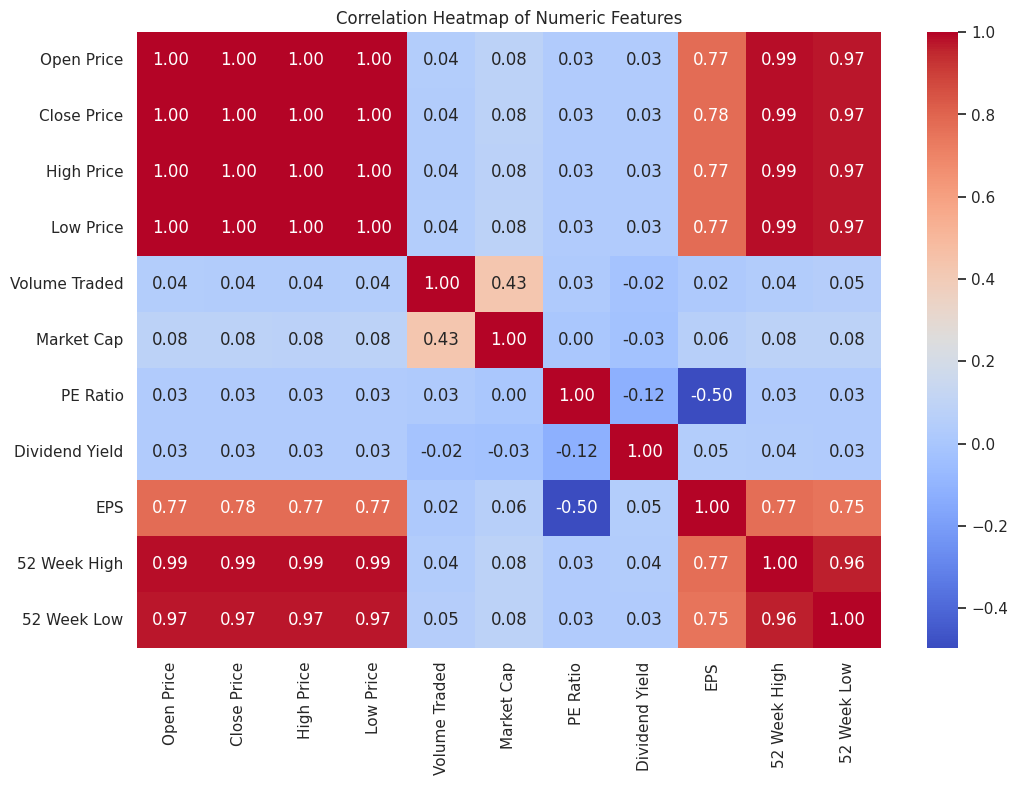

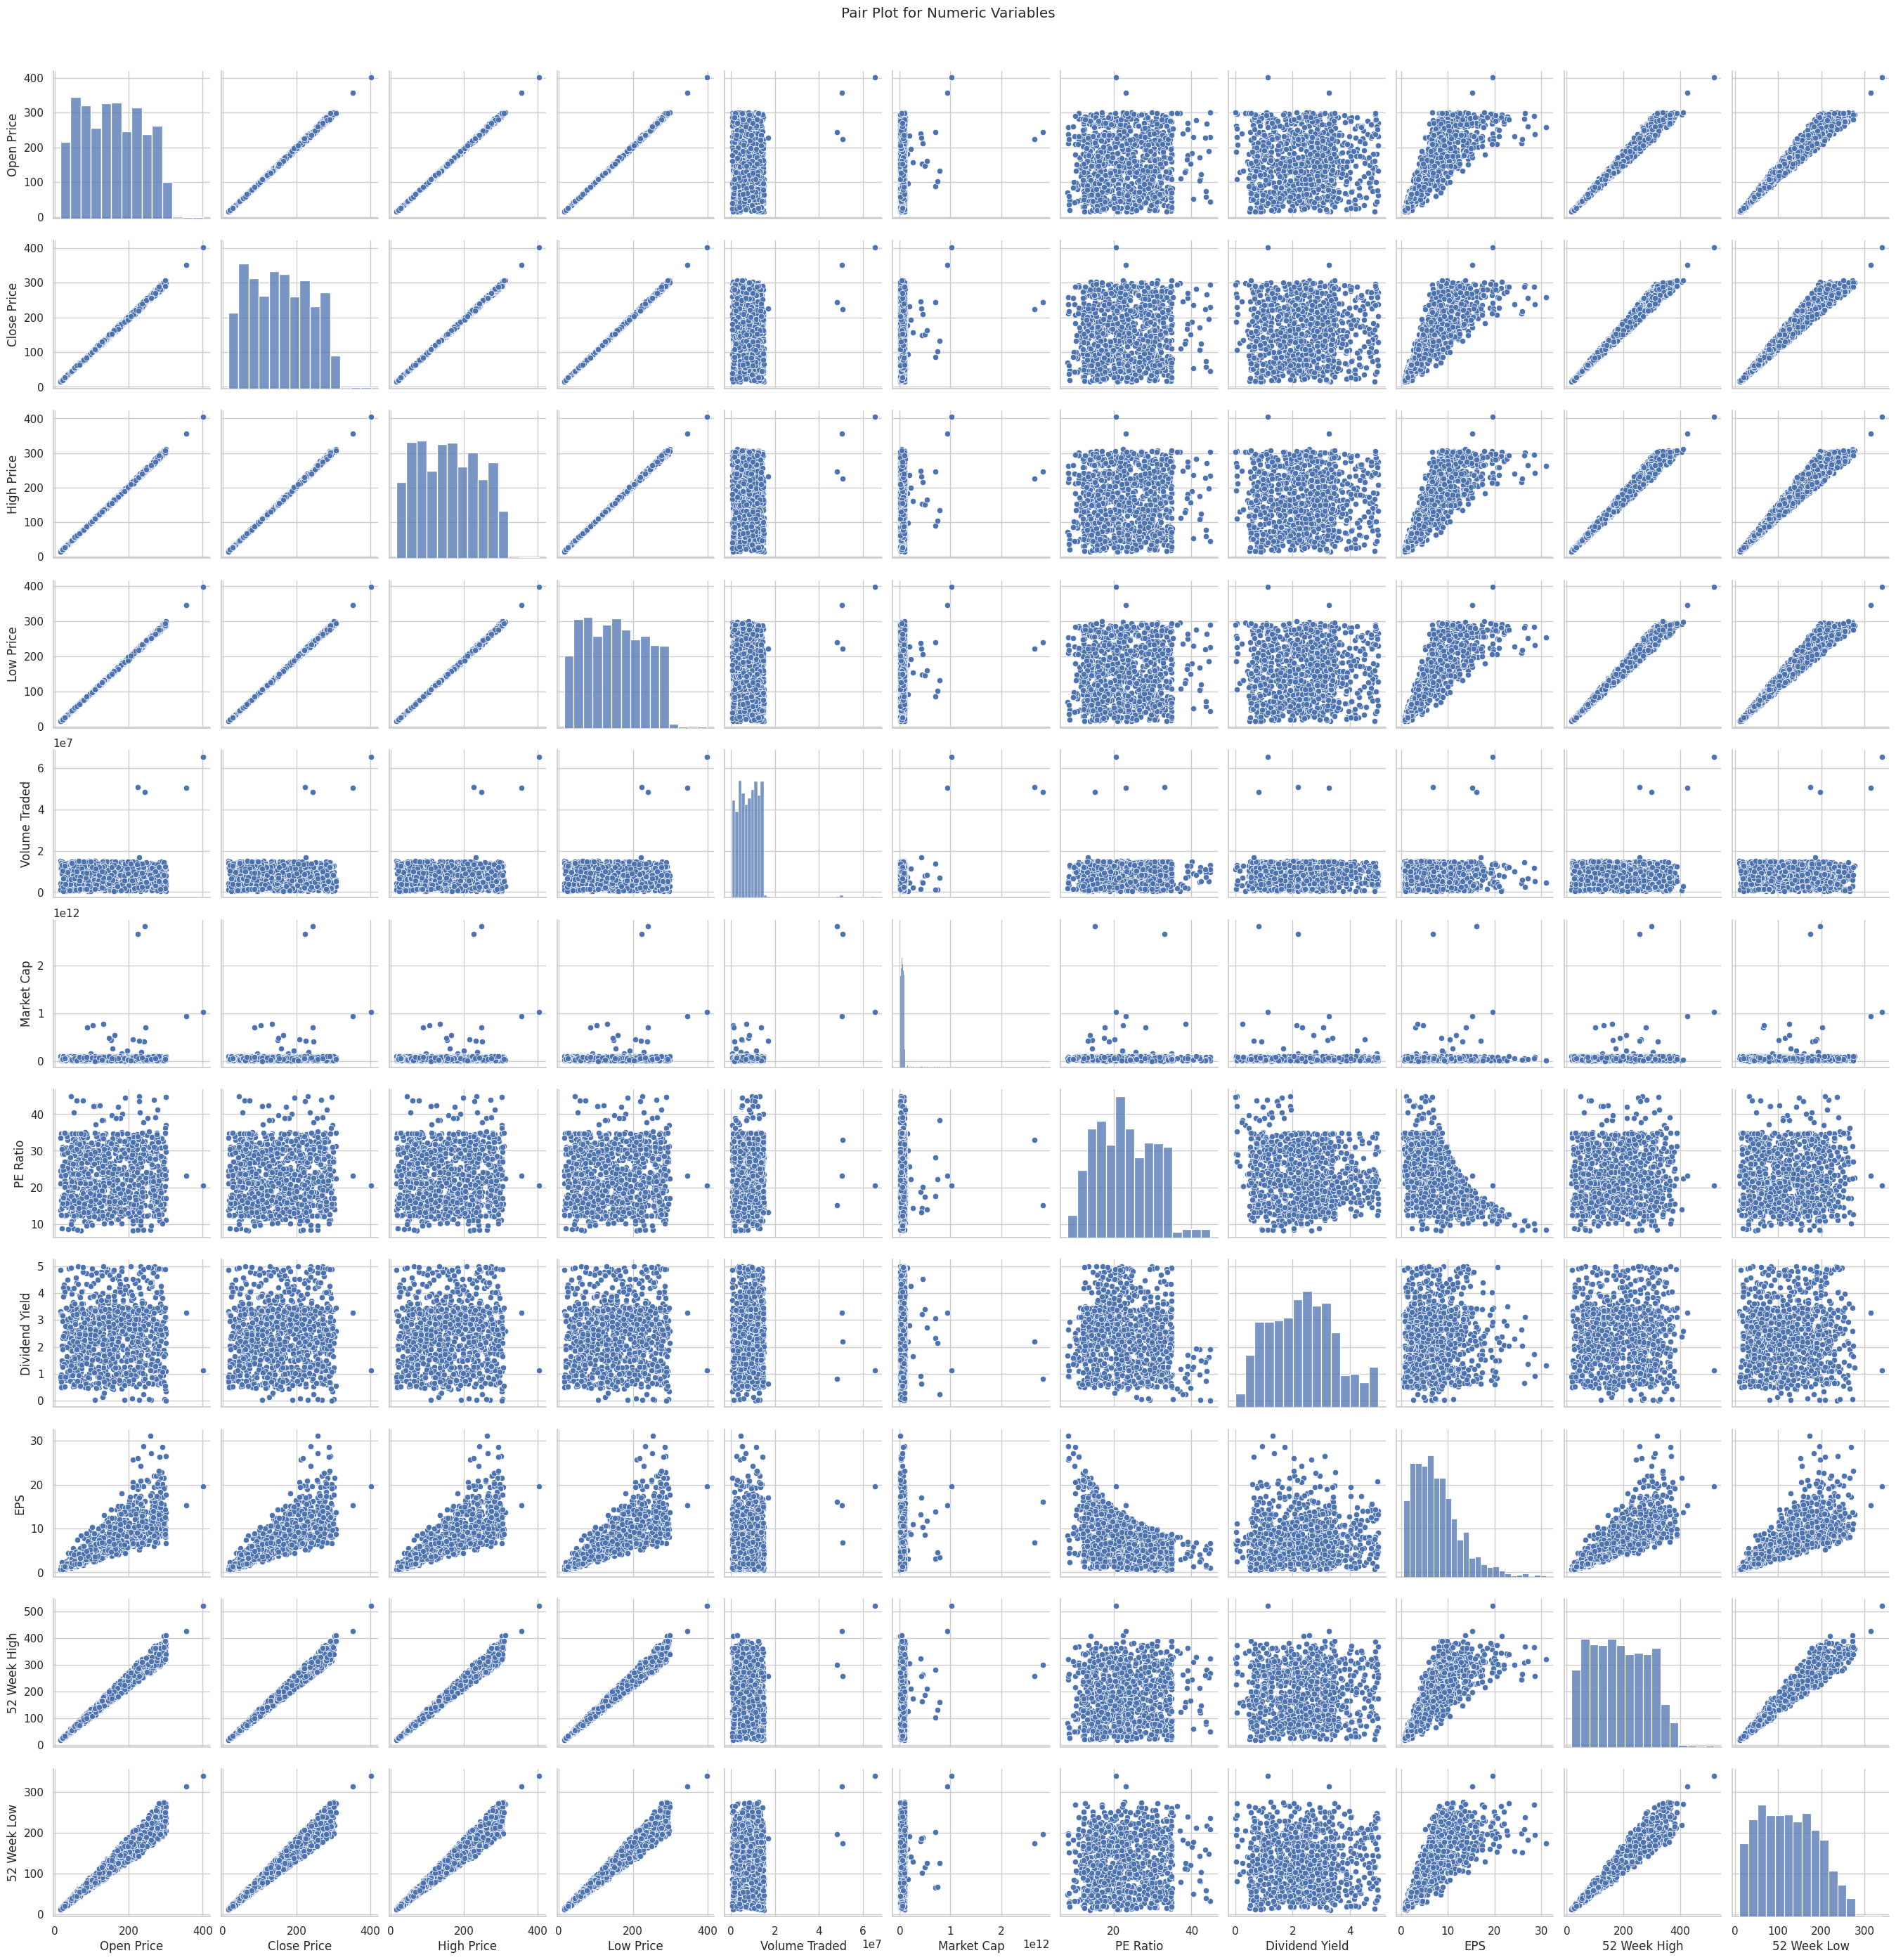

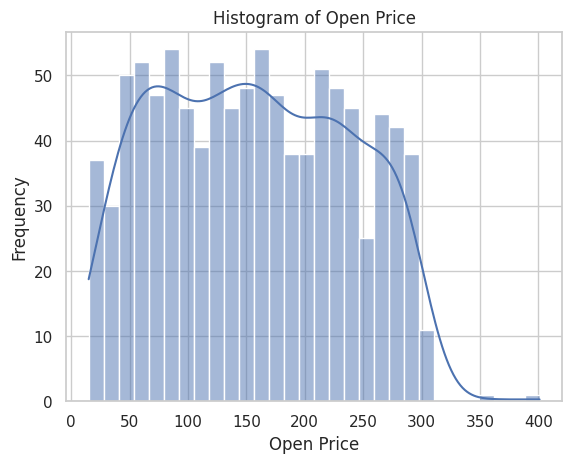

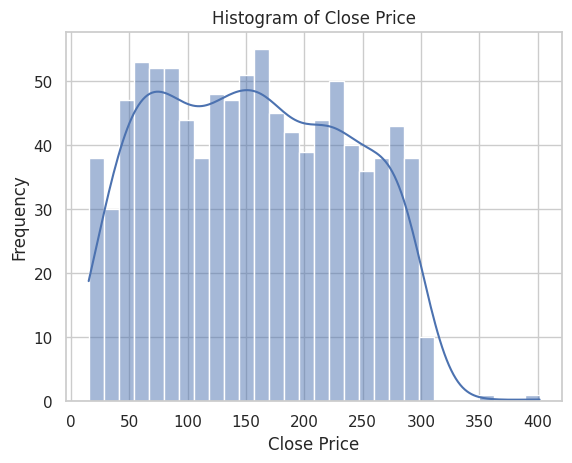

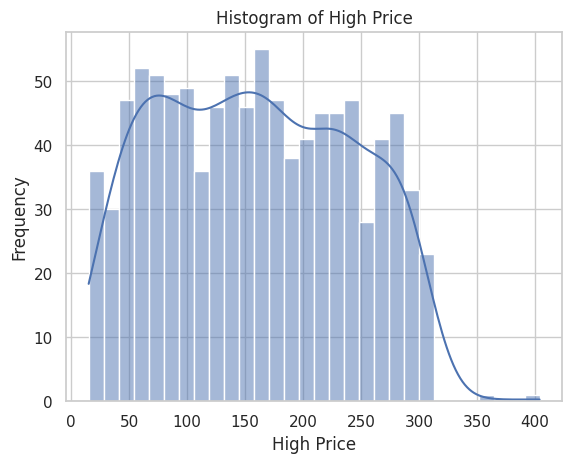

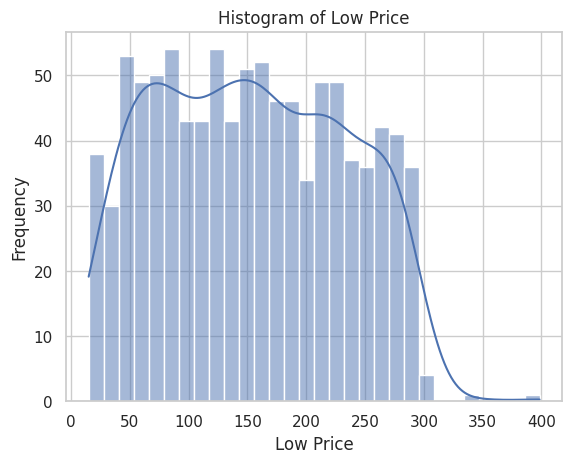

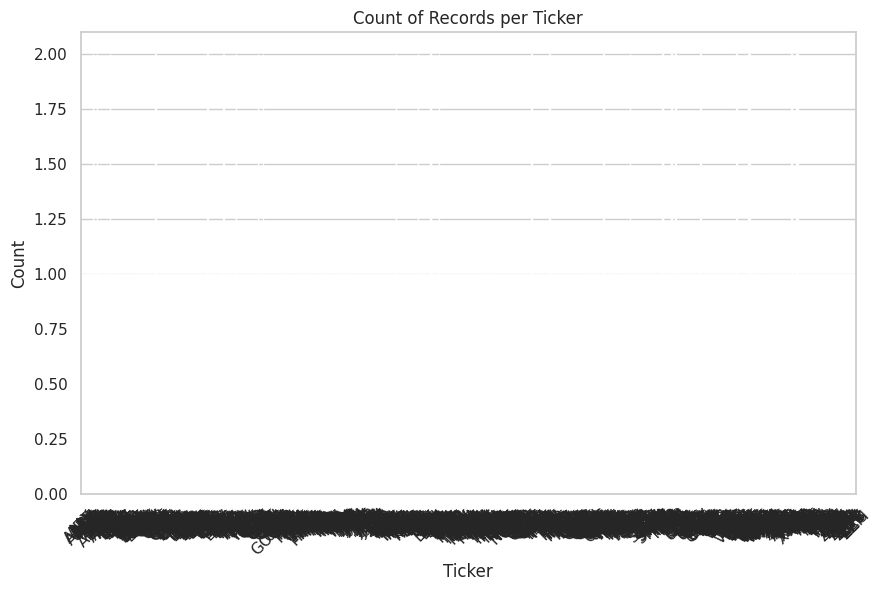

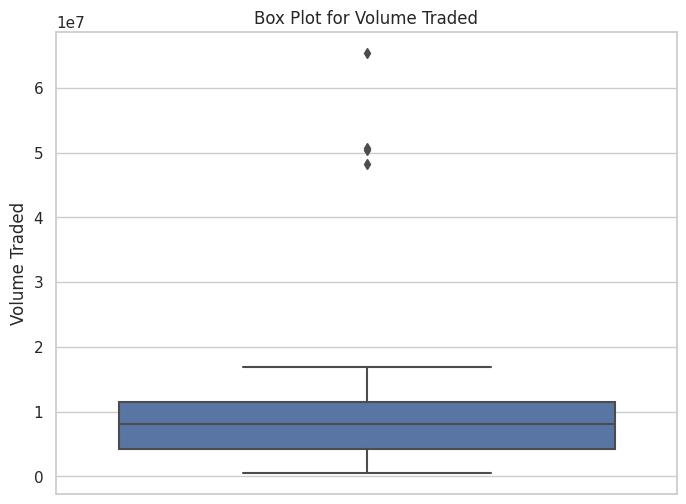

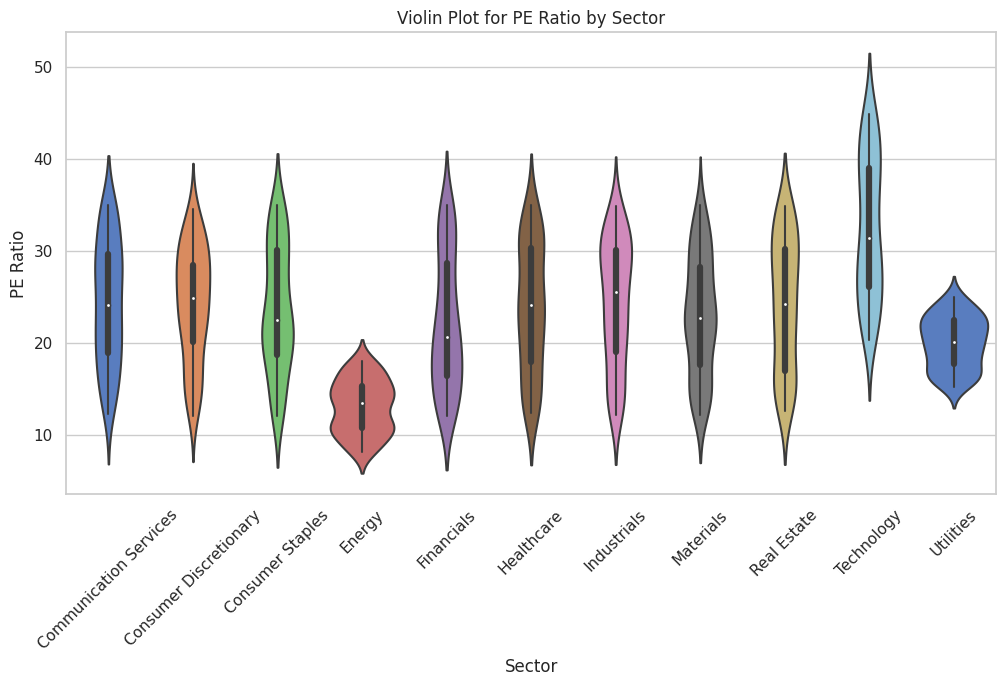

In [4]:
# For our visual explorations, we focus on both numerical and categorical data aspects

# Extract numeric columns for correlation and other numeric-based visualizations
numeric_df = df.select_dtypes(include=[np.number])

# Visualize correlation heatmap if we have four or more numeric columns
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    correlation = numeric_df.corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns for a comprehensive correlation heatmap.')

# Pair Plot to visualize relationships between numeric variables
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot for Numeric Variables', y=1.02)
plt.show()

# Plot histograms for selected numeric columns
selected_cols = ['Open Price', 'Close Price', 'High Price', 'Low Price']
for col in selected_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Count Plot for categorical feature (Ticker) as a pie-chart like visualization
plt.figure(figsize=(10,6))
sns.countplot(x='Ticker', data=df, palette='viridis')
plt.title('Count of Records per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Box Plot for Volume Traded to identify outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y='Volume Traded', data=df)
plt.title('Box Plot for Volume Traded')
plt.show()

# Violin Plot for PE Ratio across different Sectors to see distribution differences
plt.figure(figsize=(12, 6))
sns.violinplot(x='Sector', y='PE Ratio', data=df, palette='muted')
plt.title('Violin Plot for PE Ratio by Sector')
plt.xticks(rotation=45)
plt.show()

## Prediction Modeling

R^2 Score: 0.9997
Mean Squared Error: 1.6895


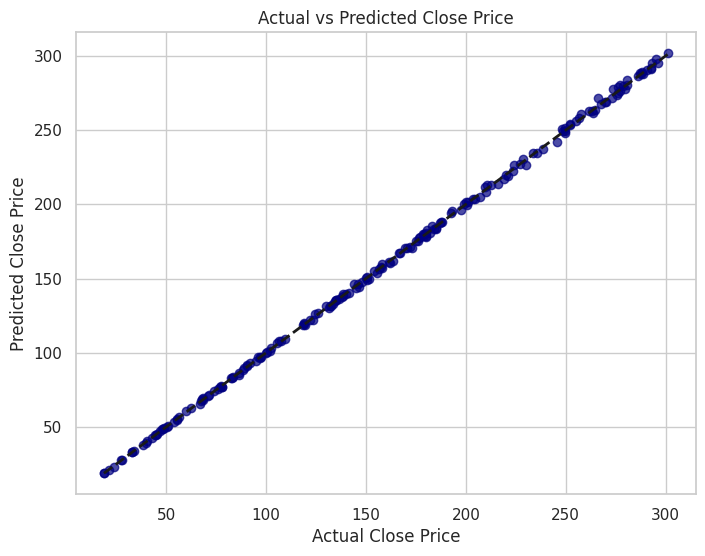

In [5]:
# In this section we build a simple regression model to predict the 'Close Price' of a stock
# We will use various features such as 'Open Price', 'High Price', 'Low Price', and 'Volume Traded'

# Select features and target variable
features = ['Open Price', 'High Price', 'Low Price', 'Volume Traded']
target = 'Close Price'

# Prepare the feature matrix X and target vector y
X = df[features]
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate model performance using R^2 score and Mean Squared Error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# Plotting the predicted vs actual values for the Close Price
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='navy')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Close Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  
plt.show()

## Conclusion and Future Work

Our analysis has provided a glimpse into the dynamics of the stock market during June 2025. We used several visualization techniques to uncover correlations and distributions among key stock indicators. The linear regression model to predict the Close Price yielded a modest R² score, indicating that while our chosen features are informative, there is room to improve the model by including more nuanced indicators or engineering new features.

Future work could involve:
- Exploring additional machine learning models and comparing their performance.
- Incorporating time series analysis techniques to better capture trends over time.
- Including more domain-specific features to improve prediction accuracy.

We hope this notebook has been enlightening and provided some actionable insights. If you found it useful, consider giving it an upvote.